## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tldextract
from pathlib import Path
plt.rcParams['font.family'] = 'Arial'

Matplotlib is building the font cache; this may take a moment.


## Global Configuration

In [2]:
# ── Directories ──────────────────────────────────────────────────────────────
BASE_1ST   = "../dataset/AdHoc_Report_1stPartyCookie"
BASE_3RD   = "../dataset/AdHoc_Report_Tracking_ListReceivedGCLID"
DIR_OUTPUT_DATA = 'output_data'
DIR_OUTPUT_FIGS = 'output_figs'

# ── Countries & flows ────────────────────────────────────────────────────────
COUNTRY_LABELS = {
    'AU': 'Australia',
    'DE': 'Germany',
    'BR': 'Brazil',
    'JP': 'Japan',
    'US': 'United States',
    'ZA': 'South Africa',
}
COUNTRIES   = list(COUNTRY_LABELS.keys())
FULL_NAMES  = list(COUNTRY_LABELS.values())
FLOWS       = ['accept-all', 'reject-all', 'no-interaction']
REQ_TYPES   = ['Accept All', 'Reject All', 'No Interaction', 'No Banner']

# ── 1st-party cookie CSV paths ───────────────────────────────────────────────
FILES_1ST = {
    c: {f: f"{BASE_1ST}/1st_party_cookie_{c}_{f}.csv" for f in FLOWS}
    for c in COUNTRIES
}

# ── Run columns ──────────────────────────────────────────────────────────────
RUN_COLS = ['run_1', 'run_2', 'run_3', 'run_4', 'run_5']

# ── Shared colour palette ────────────────────────────────────────────────────
COLORS = {
    "correct":    "#1D9E75",
    "always_set": "#B84040",
    "never_set":  "#73726C",
}
COLOR_BANNER = '#3266ad'

## Shared Helper Functions

In [3]:
def get_registered_domain(url):
    """Return the registered domain (e.g. 'google.com') from a URL, or None."""
    if pd.isna(url):
        return None
    ext = tldextract.extract(str(url))
    if ext.domain and ext.suffix:
        return f"{ext.domain}.{ext.suffix}"
    return ext.domain or None


def normalize_yes_no(x):
    """Normalise a cell value to 'yes', 'no', or None."""
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    return x if x in {"yes", "no"} else None


def safe_pct(numerator, denominator):
    """Return percentage rounded to 1 dp, or 0.0 if denominator is zero."""
    return round(numerator / denominator * 100, 1) if denominator > 0 else 0.0


def label_bar_segments(ax, bars, bottoms):
    """Add centred percentage labels to stacked bar segments >= 5 % tall."""
    for bar, bottom in zip(bars, bottoms):
        h = bar.get_height()
        if h >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom + h / 2,
                f"{h:.1f}%",
                ha='center', va='center',
                fontsize=13, color='white', fontweight='bold',
            )
            #ax.text(bar.get_x() + bar.get_width() / 2, bottom + h / 2, f"{h:.1f}%", ha='center', va='center', fontsize=13, color='white', fontproperties=helvetica_bold)


def bold_legend(legend):
    """Make all legend text bold."""
    for text in legend.get_texts():
        #text.set_fontproperties(helvetica_bold)
        text.set_fontweight('bold')

In [5]:
import csv
def count_unique_advertisers(csv_file_path):
    unique_advertisers = set()
    
    with open(csv_file_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            domain = get_registered_domain(row.get('advertiser_url', ''))
            if domain:
                unique_advertisers.add(domain)
    
    print(f"Total unique advertisers: {len(unique_advertisers)}")
    print("\nUnique advertiser domains:")
    for advertiser in sorted(unique_advertisers):
        print(f"  - {advertiser}")
    
    return unique_advertisers

# Run it
unique = count_unique_advertisers('../dataset/AdHoc_Report_1stPartyCookie/1st_party_cookie_AU_accept-all.csv')

Total unique advertisers: 1502

Unique advertiser domains:
  - 1021viadelgato.com
  - 12go.asia
  - 16bayview.com
  - 16types.ai
  - 188weststjames.com
  - 1und1.net
  - 2509madronaavenue.com
  - 2699coconutgrove.com
  - 4002vialaguna.com
  - 4nsi.com
  - 4x4megaworldonline.com
  - 706sf.com
  - 99app.com
  - a1autorentalgd.com
  - a4ldalton.com
  - aafp.org
  - abbexa.com
  - abematv.co.jp
  - about
  - abretuchildcare.com
  - abridge.com
  - absolutradio.de
  - abstract-astro.com
  - accendo.co.jp
  - accor.com
  - acf.org.au
  - acrartex.com
  - acres.com
  - actionagainsthunger.org
  - adcomayogel.co.za
  - adcs.co.il
  - adobe.com
  - adt.co.za
  - advancedclinical.com
  - advancedwaterfront.com
  - adventureindustries.com.au
  - adviceacademy.au
  - aeiseminars.com
  - aeonretail.jp
  - affordabletours.com
  - afilio.de
  - afrox.co.za
  - agc-electronics.com
  - agilecrm.com
  - agriskills.net
  - air.diet
  - airchilly.com
  - aixpad.de
  - ajmc.com
  - akiya-kaitoritai.com
  -

In [6]:
import pandas as pd
from urllib.parse import urlparse

# Load your CSV
df = pd.read_csv("../dataset/AdHoc_Report_1stPartyCookie/1st_party_cookie_AU_accept-all.csv")

# Function to extract domain
def extract_domain(url):
    try:
        return urlparse(url).netloc.lower()
    except:
        return None

# Apply extraction
df['domain'] = df['gg_ads_url'].dropna().apply(get_registered_domain)

# Get unique domains
unique_domains = sorted(df['domain'].dropna().unique())

print(f"Total unique domains: {len(unique_domains)}")
print(unique_domains)

Total unique domains: 3
['doubleclick.net', 'googleadservices.com', 'googlesyndication.com']


## 1st-Party Cookie – Data Loaders

In [7]:
def get_domain_level_df(filepath):
    """
    Load a 1st-party cookie CSV and return a domain-indexed DataFrame with:
      - observed : bool  – at least one run value present
      - any_yes  : bool  – at least one run value is 'yes'
    """
    try:
        df = pd.read_csv(filepath)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        return pd.DataFrame(
            columns=["observed", "any_yes"]
        ).set_index(pd.Index([], name="domain"))

    df["domain"] = df["advertiser_url"].apply(get_registered_domain)
    df = df.dropna(subset=["domain"])
    for col in RUN_COLS:
        df[col] = df[col].apply(normalize_yes_no)

    records = []
    for domain, g in df.groupby("domain"):
        values = g[RUN_COLS].stack().dropna().tolist()
        records.append({
            "domain":   domain,
            "observed": len(values) > 0,
            "any_yes":  any(v == "yes" for v in values),
        })
    return pd.DataFrame(records).set_index("domain")


def get_domain_list(country):
    """
    Return the set of domains eligible for analysis in a given country:
    those observed in both accept-all & reject-all, OR in neither
    (no-banner sites).
    """
    accept_df = get_domain_level_df(FILES_1ST[country]['accept-all'])
    reject_df = get_domain_level_df(FILES_1ST[country]['reject-all'])
    no_df     = get_domain_level_df(FILES_1ST[country]['no-interaction'])

    all_domains = accept_df.index.union(reject_df.index).union(no_df.index)
    accept_obs  = accept_df.reindex(all_domains, fill_value=False)["observed"]
    reject_obs  = reject_df.reindex(all_domains, fill_value=False)["observed"]

    has_both_banner = accept_obs & reject_obs
    has_no_banner   = ~(accept_obs | reject_obs)
    return set(all_domains[has_both_banner | has_no_banner])

## 1st-Party Cookie – Build Intersection & Compute Behaviour Stats

In [8]:
# ── Intersection domain set (present in every country dataset) ───────────────
sets_per_country    = [get_domain_list(c) for c in COUNTRIES]
intersected_domains = set.intersection(*sets_per_country)
INTERSECT_INDEX     = pd.Index(sorted(intersected_domains), name="domain")
INTERSECT_COUNT     = len(INTERSECT_INDEX)
print(f"Number of Advertisers: {INTERSECT_COUNT}")

# ── Behaviour categories (mutually exclusive, computed over valid domains) ───
#
#   Exclusions (removed from denominator – crawl artefacts):
#     inverted    : accept=no,  reject=yes
#     no_int_only : reject=no,  no-int=yes  (and reject≠yes)
#
#   Remaining categories:
#     correct    : accept=yes, reject=no,  no-int=no   ← compliant
#     always_set : accept=yes, reject=yes              ← violation
#     never_set  : accept=no,  reject=no,  no-int=no   ← never sets
# ─────────────────────────────────────────────────────────────────────────────
results = {}

for country in COUNTRIES:
    accept_s = get_domain_level_df(FILES_1ST[country]['accept-all']).reindex(INTERSECT_INDEX, fill_value=False)
    reject_s = get_domain_level_df(FILES_1ST[country]['reject-all']).reindex(INTERSECT_INDEX, fill_value=False)
    no_s     = get_domain_level_df(FILES_1ST[country]['no-interaction']).reindex(INTERSECT_INDEX, fill_value=False)

    can_both = accept_s["observed"] & reject_s["observed"]

    # No-banner subset
    has_banner_mask       = accept_s["observed"] | reject_s["observed"]
    no_banner_mask        = ~has_banner_mask
    n_no_banner           = int(no_banner_mask.sum())
    no_banner_sets_cookie = int((no_banner_mask & no_s["any_yes"]).sum())

    # Shorthand boolean Series for can_both domains
    a_yes = accept_s["any_yes"] & can_both
    a_no  = ~accept_s["any_yes"] & can_both
    r_yes = reject_s["any_yes"] & can_both
    r_no  = ~reject_s["any_yes"] & can_both
    n_no  = ~no_s["any_yes"] & can_both

    inverted_mask    = a_no & r_yes
    no_int_only_mask = r_no & no_s["any_yes"] & can_both & ~r_yes
    excluded_mask    = inverted_mask | no_int_only_mask

    valid      = can_both & ~excluded_mask
    n_valid    = int(valid.sum())
    n_can_both = int(can_both.sum())

    correct    = int((valid & a_yes & r_no & n_no).sum())
    always_set = int((valid & a_yes & r_yes).sum())
    never_set  = int((valid & a_no  & r_no & n_no).sum())

    results[country] = {
        # Behaviour categories
        "n_valid":        n_valid,
        "correct":        correct,
        "always_set":     always_set,
        "never_set":      never_set,
        "pct_correct":    safe_pct(correct,    n_valid),
        "pct_always_set": safe_pct(always_set, n_valid),
        "pct_never_set":  safe_pct(never_set,  n_valid),
        "excluded":       int(excluded_mask.sum()),
        # Banner-presence stats
        "can_both_observed":         n_can_both,
        "accept_yes":                int((can_both & accept_s["any_yes"]).sum()),
        "accept_yes_%":              safe_pct(int((can_both & accept_s["any_yes"]).sum()), n_can_both),
        "reject_yes":                int((can_both & reject_s["any_yes"]).sum()),
        "reject_yes_%":              safe_pct(int((can_both & reject_s["any_yes"]).sum()), n_can_both),
        "no_interact_yes":           int((can_both & no_s["any_yes"]).sum()),
        "no_interact_yes_%":         safe_pct(int((can_both & no_s["any_yes"]).sum()), n_can_both),
        "no_banner_count":           n_no_banner,
        "no_banner_sets_cookie":     no_banner_sets_cookie,
        "no_banner_sets_cookie_pct": safe_pct(no_banner_sets_cookie, n_no_banner),
    }

# ── Save summary ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(results).T
print(f"\nAnalysis based on {INTERSECT_COUNT} domains present in all country datasets.\n")
print(summary_df.to_string())

Number of Advertisers: 1412

Analysis based on 1412 domains present in all country datasets.

    n_valid  correct  always_set  never_set  pct_correct  pct_always_set  pct_never_set  excluded  can_both_observed  accept_yes  accept_yes_%  reject_yes  reject_yes_%  no_interact_yes  no_interact_yes_%  no_banner_count  no_banner_sets_cookie  no_banner_sets_cookie_pct
AU    472.0     92.0       306.0       74.0         19.5            64.8           15.7       6.0              478.0       402.0          84.1       306.0          64.0            310.0               64.9            934.0                  738.0                       79.0
DE    598.0    185.0       310.0      103.0         30.9            51.8           17.2       7.0              605.0       500.0          82.6       310.0          51.2            310.0               51.2            807.0                  583.0                       72.2
BR    477.0     96.0       293.0       88.0         20.1            61.4           18.4   

In [9]:
latex_rows      = []
caption_details = []

for country, res in results.items():
    name = COUNTRY_LABELS[country]
    row = (
        f"        {name}"
        f" & {res['accept_yes']} / {res['accept_yes_%']}\\%"
        f" & {res['reject_yes']} / {res['reject_yes_%']}\\%"
        f" & {res['no_interact_yes']} / {res['no_interact_yes_%']}\\%"
        f" & {res['no_banner_sets_cookie']} / {res['no_banner_sets_cookie_pct']}\\% \\\\"
    )
    latex_rows.append(row)
    caption_details.append(
        f"{name} (n={res['can_both_observed']} with banner, n={res['no_banner_count']} without)"
    )

header = (
    "\\begin{table}[t!]\n"
    "    \\centering\n"
    "    \\small\n"
    "    \\begin{tabular}{l|ccc|c}\n"
    "    \\toprule\n"
    "        & \\multicolumn{3}{c|}{\\textbf{Banner Present}} & \\textbf{No Banner} \\\\\n"
    "        \\textbf{Country} & \\textbf{Accept All} & \\textbf{Reject All}"
    " & \\textbf{No Interaction} & \\textbf{Sets Cookie} \\\\\n"
    "        \\midrule\n"
)

rows_block = "\n".join(latex_rows)

footer = (
    "\n        \\bottomrule\n"
    "    \\end{tabular}\n"
    "\\caption{Advertisers setting gclid as a first-party cookie by banner interaction.\n"
    "Entries are count/percentage. Analyzed domains: "
    + "; ".join(caption_details)
    + ".}\n"
    "    \\label{tab:gclid_breakdown}\n"
    "\\end{table}"
)

latex_table = header + rows_block + footer

print("\n--- Generated LaTeX Table ---\n")
print(latex_table)
with open(f"{DIR_OUTPUT_DATA}/cookie_analysis_table.tex", "w") as f:
    f.write(latex_table)



--- Generated LaTeX Table ---

\begin{table}[t!]
    \centering
    \small
    \begin{tabular}{l|ccc|c}
    \toprule
        & \multicolumn{3}{c|}{\textbf{Banner Present}} & \textbf{No Banner} \\
        \textbf{Country} & \textbf{Accept All} & \textbf{Reject All} & \textbf{No Interaction} & \textbf{Sets Cookie} \\
        \midrule
        Australia & 402 / 84.1\% & 306 / 64.0\% & 310 / 64.9\% & 738 / 79.0\% \\
        Germany & 500 / 82.6\% & 310 / 51.2\% & 310 / 51.2\% & 583 / 72.2\% \\
        Brazil & 390 / 80.6\% & 293 / 60.5\% & 296 / 61.2\% & 703 / 75.8\% \\
        Japan & 394 / 82.9\% & 308 / 64.8\% & 310 / 65.3\% & 752 / 80.3\% \\
        United States & 415 / 82.3\% & 323 / 64.1\% & 325 / 64.5\% & 721 / 79.4\% \\
        South Africa & 389 / 81.9\% & 295 / 62.1\% & 295 / 62.1\% & 734 / 78.3\% \\
        \bottomrule
    \end{tabular}
\caption{Advertisers setting gclid as a first-party cookie by banner interaction.
Entries are count/percentage. Analyzed domains: Australia (n=

Australia: 33.9% of advertisers have a banner. 478/1412
Germany: 42.8% of advertisers have a banner. 605/1412
Brazil: 34.3% of advertisers have a banner. 484/1412
Japan: 33.6% of advertisers have a banner. 475/1412
United States: 35.7% of advertisers have a banner. 504/1412
South Africa: 33.6% of advertisers have a banner. 475/1412


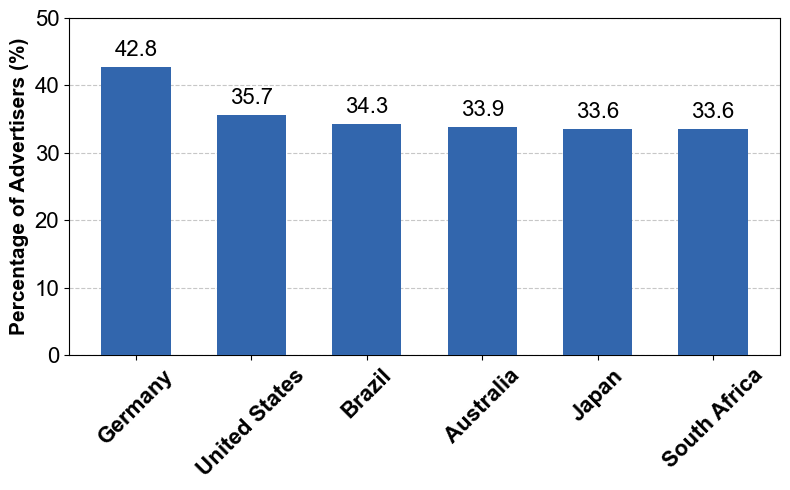

In [10]:
for country, res in results.items():
    total = res['can_both_observed'] + res['no_banner_count']
    res['pct_banner'] = safe_pct(res['can_both_observed'], total)
    print(f"{COUNTRY_LABELS[country]}: {res['pct_banner']}% of advertisers have a banner. {res['can_both_observed']}/{total}")

sorted_banner = sorted(results.items(), key=lambda x: x[1]["pct_banner"], reverse=True)
labels_b = [COUNTRY_LABELS[c] for c, _ in sorted_banner]
pct_with = [v["pct_banner"] for _, v in sorted_banner]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(sorted_banner)), pct_with, color=COLOR_BANNER, width=0.6, zorder=3)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}",
        ha='center', va='bottom', fontsize=16,
    )

ax.set_xticks(range(len(sorted_banner)))
ax.set_xticklabels(labels_b, fontsize=16, rotation=45, weight='bold')
#ax.set_xticklabels(labels_b, fontsize=16, rotation=45, fontproperties=helvetica_bold)
ax.set_ylabel('Percentage of Advertisers (%)', fontsize=15, weight='bold')
#ax.set_ylabel('Percentage of Advertisers (%)', fontsize=16, fontproperties=helvetica_bold)
ax.set_ylim(0, 50)
plt.yticks(fontsize=16)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{DIR_OUTPUT_FIGS}/cookie_banner_by_country.pdf', format='pdf')
plt.show()

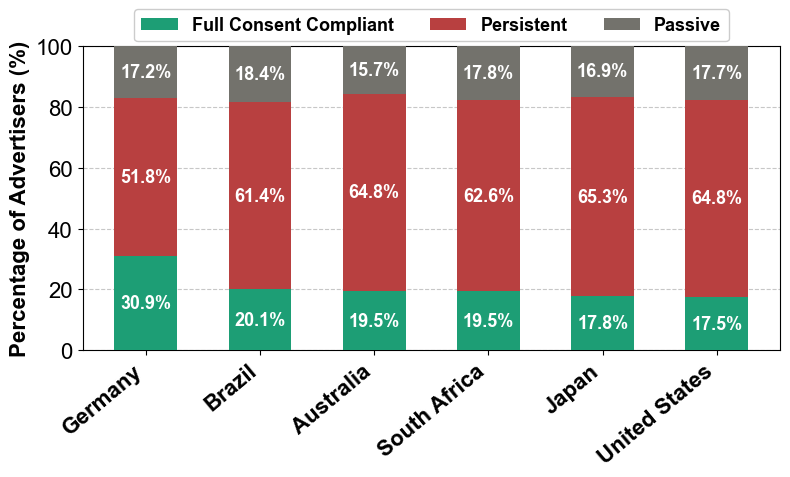

In [11]:
sorted_items     = sorted(results.items(), key=lambda x: x[1]["pct_correct"], reverse=True)
labels           = [COUNTRY_LABELS[c] for c, _ in sorted_items]
pct_correct      = [v["pct_correct"]    for _, v in sorted_items]
pct_always_set   = [v["pct_always_set"] for _, v in sorted_items]
pct_never_set    = [v["pct_never_set"]  for _, v in sorted_items]

x     = range(len(sorted_items))
width = 0.55

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x, pct_correct,    width, label="Full Consent Compliant", color=COLORS["correct"],    zorder=3)
b2 = ax.bar(x, pct_always_set, width, label="Persistent",              color=COLORS["always_set"], zorder=3,
            bottom=pct_correct)
b3 = ax.bar(x, pct_never_set,  width, label="Passive",                 color=COLORS["never_set"],  zorder=3,
            bottom=[a + b for a, b in zip(pct_correct, pct_always_set)])

zeros = [0] * len(sorted_items)
label_bar_segments(ax, b1, zeros)
label_bar_segments(ax, b2, pct_correct)
label_bar_segments(ax, b3, [a + b for a, b in zip(pct_correct, pct_always_set)])

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentage of Advertisers (%)', fontsize=16, fontweight='bold')
# ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=16, fontproperties=helvetica_bold)
# ax.set_ylabel('Percentage of Advertisers (%)', fontsize=16, fontproperties=helvetica_bold)
ax.set_ylim(0, 100)
plt.yticks(fontsize=16)

legend = ax.legend(fontsize=13, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, framealpha=1)
bold_legend(legend)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{DIR_OUTPUT_FIGS}/consent_compliance_stacked.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [12]:


# -------------------------------------------------------------------
# Save per-country domain lists for:
#   1. Full Compliance  -> correct
#   2. Persistent       -> always_set
#   3. Passive          -> never_set
# -------------------------------------------------------------------

out_dir = Path(DIR_OUTPUT_DATA) / "country_behaviour_lists"
out_dir.mkdir(parents=True, exist_ok=True)

for country in COUNTRIES:
    accept_s = get_domain_level_df(FILES_1ST[country]['accept-all']).reindex(INTERSECT_INDEX, fill_value=False)
    reject_s = get_domain_level_df(FILES_1ST[country]['reject-all']).reindex(INTERSECT_INDEX, fill_value=False)
    no_s     = get_domain_level_df(FILES_1ST[country]['no-interaction']).reindex(INTERSECT_INDEX, fill_value=False)

    can_both = accept_s["observed"] & reject_s["observed"]

    a_yes = accept_s["any_yes"] & can_both
    a_no  = ~accept_s["any_yes"] & can_both
    r_yes = reject_s["any_yes"] & can_both
    r_no  = ~reject_s["any_yes"] & can_both
    n_no  = ~no_s["any_yes"] & can_both

    inverted_mask    = a_no & r_yes
    no_int_only_mask = r_no & no_s["any_yes"] & can_both & ~r_yes
    excluded_mask    = inverted_mask | no_int_only_mask

    valid = can_both & ~excluded_mask

    # Category masks
    full_compliance_mask = valid & a_yes & r_no & n_no
    persistent_mask      = valid & a_yes & r_yes
    passive_mask         = valid & a_no  & r_no & n_no

    # Convert masks to DataFrames
    full_compliance_df = pd.DataFrame({"domain": INTERSECT_INDEX[full_compliance_mask]})
    persistent_df      = pd.DataFrame({"domain": INTERSECT_INDEX[persistent_mask]})
    passive_df         = pd.DataFrame({"domain": INTERSECT_INDEX[passive_mask]})

    # Optional: sort alphabetically
    full_compliance_df = full_compliance_df.sort_values("domain").reset_index(drop=True)
    persistent_df      = persistent_df.sort_values("domain").reset_index(drop=True)
    passive_df         = passive_df.sort_values("domain").reset_index(drop=True)

    # Save files
    full_compliance_df.to_csv(out_dir / f"{country}_full_compliance.csv", index=False)
    persistent_df.to_csv(out_dir / f"{country}_persistent.csv", index=False)
    passive_df.to_csv(out_dir / f"{country}_passive.csv", index=False)

    print(
        f"{country}: saved "
        f"{len(full_compliance_df)} full_compliance, "
        f"{len(persistent_df)} persistent, "
        f"{len(passive_df)} passive domains"
    )

AU: saved 92 full_compliance, 306 persistent, 74 passive domains
DE: saved 185 full_compliance, 310 persistent, 103 passive domains
BR: saved 96 full_compliance, 293 persistent, 88 passive domains
JP: saved 84 full_compliance, 308 persistent, 80 passive domains
US: saved 87 full_compliance, 322 persistent, 88 passive domains
ZA: saved 92 full_compliance, 295 persistent, 84 passive domains


In [13]:
# ── ANALYZING CONSISTENCY ACROSS ALL COUNTRIES ────────────────────────────────

out_dir = Path(DIR_OUTPUT_DATA) / "country_behaviour_lists"

def load_domain_set(country, behaviour):
    path = out_dir / f"{country}_{behaviour}.csv"
    return set(pd.read_csv(path)["domain"].tolist())

# ── Load domain sets per behaviour per country ───────────────────────────────
correct_sets = {c: load_domain_set(c, "full_compliance") for c in COUNTRIES}
always_sets  = {c: load_domain_set(c, "persistent")      for c in COUNTRIES}
never_sets   = {c: load_domain_set(c, "passive")          for c in COUNTRIES}  # ← was "never_set"

# ── Intersect across ALL countries ───────────────────────────────────────────
consistent_correct    = set.intersection(*correct_sets.values())
consistent_always_set = set.intersection(*always_sets.values())
consistent_never_set  = set.intersection(*never_sets.values())

n_total     = INTERSECT_COUNT
n_correct    = len(consistent_correct)
n_always_set = len(consistent_always_set)
n_never_set  = len(consistent_never_set)

print("ANALYZING CONSISTENCY ACROSS ALL COUNTRIES")
print("=" * 40)
print(f"Total domains analyzed across all countries: {n_total}")
print(f"  - Consistently Correct:    {n_correct}  ({n_correct / n_total * 100:.1f}%)")
print(f"  - Consistently Always Set: {n_always_set}  ({n_always_set / n_total * 100:.1f}%)")
print(f"  - Consistently Never Set:  {n_never_set}  ({n_never_set / n_total * 100:.1f}%)")

# ── Save consistent domain lists ─────────────────────────────────────────────
consist_dir = Path(DIR_OUTPUT_DATA) / "consistency_across_countries"
consist_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(sorted(consistent_correct),    columns=["domain"]).to_csv(consist_dir / "consistent_correct.csv",    index=False)
pd.DataFrame(sorted(consistent_always_set), columns=["domain"]).to_csv(consist_dir / "consistent_always_set.csv", index=False)
pd.DataFrame(sorted(consistent_never_set),  columns=["domain"]).to_csv(consist_dir / "consistent_never_set.csv",  index=False)

print(f"\nConsistent domain lists saved to: {consist_dir}")

ANALYZING CONSISTENCY ACROSS ALL COUNTRIES
Total domains analyzed across all countries: 1412
  - Consistently Correct:    64  (4.5%)
  - Consistently Always Set: 207  (14.7%)
  - Consistently Never Set:  63  (4.5%)

Consistent domain lists saved to: output_data/consistency_across_countries


/var/folders/2n/7jzydt7962sf146gkw261k4r0000gn/T/ipykernel_54227/3779331891.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  crux = pd.read_csv(f, header=None, names=["origin", "rank"])


Full Consent Compliant: matched 2/64, not found: ['1und1.net', 'afilio.de', 'agriskills.net', 'aixpad.de', 'alarm-it-factory.de', 'alphawave.fund', 'athletec.de', 'avis.co.za', 'bayer.com.au', 'bentleymotors.com', 'birkenstock.com', 'brandregistrygroup.org', 'budget.co.za', 'buildrightlawyers.com', 'citeline.com', 'congatec.com', 'conword.io', 'corporategold.de', 'costruzionibergamo.com', 'daikin.co.za', 'denhartogh.com', 'ebjournal.com', 'ed.ac.uk', 'esta.com', 'etonshirts.com', 'eyefactive.com', 'fendt.com', 'firzt.co.za', 'fluxtrol.com', 'fourth.com', 'gesundheits-praemien.de', 'greencomics.io', 'grimco.com', 'happy-sim.de', 'hidglobal.com', 'hutchinsonai.com', 'ihmvcu.org', 'kibek.de', 'knaus.com', 'kress.com', 'l3harris.com', 'luna-storage.com', 'marketstar.com', 'mobacoffee.de', 'motusmg.co.za', 'myvoy.de', 'naitec.ai', 'onestream.com', 'pod.international', 'psychiczoltan.com', 'pulpstream.com', 'rohstoff-recycling-kuehn.de', 'royaltyexchange.com', 'sedaexperts.com', 'segmueller.

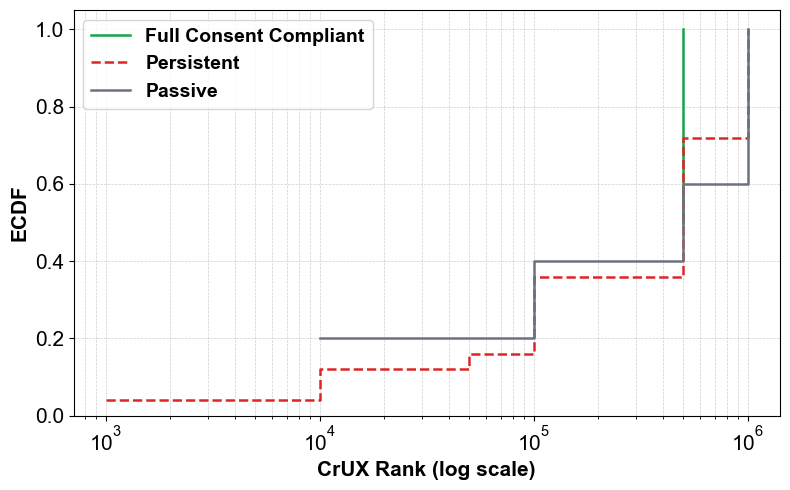

In [14]:
import pandas as pd
import gzip
import matplotlib.pyplot as plt
import numpy as np

# Load CrUX
with gzip.open("current.csv.gz", "rt") as f:
    crux = pd.read_csv(f, header=None, names=["origin", "rank"])

crux["domain"] = (
    crux["origin"]
    .str.replace(r"https?://", "", regex=True)
    .str.rstrip("/")
)
crux["rank"] = pd.to_numeric(crux["rank"], errors="coerce")
crux = crux.dropna(subset=["rank"])
crux["rank"] = crux["rank"].astype(int)

# Load behavior CSVs
full       = pd.read_csv("output_data/consistency_across_countries/consistent_correct.csv")["domain"].str.strip()
persistent = pd.read_csv("output_data/consistency_across_countries/consistent_always_set.csv")["domain"].str.strip()
passive    = pd.read_csv("output_data/consistency_across_countries/consistent_never_set.csv")["domain"].str.strip()

behaviors = {
    "Full Consent Compliant": set(full),
    "Persistent":             set(persistent),
    "Passive":                set(passive),
}

colors = {
    "Full Consent Compliant": "#16a34a",
    "Persistent":             "#dc2626",
    "Passive":                "#6b7280",
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, domains in behaviors.items():
    matched = crux[crux["domain"].isin(domains)]["rank"]
    not_found = domains - set(crux[crux["domain"].isin(domains)]["domain"])
    print(f"{label}: matched {len(matched)}/{len(domains)}, "
          f"not found: {sorted(not_found)}")

    ranks = np.sort(matched.values)
    ecdf  = np.arange(1, len(ranks) + 1) / len(ranks)

    if label == "Persistent":
        ax.step(ranks, ecdf, where="post", color=colors[label],
                linewidth=1.8, label=label, linestyle="--")
    else:
        ax.step(ranks, ecdf, where="post", color=colors[label],
                linewidth=1.8, label=label, linestyle="-")

ax.set_xscale("log")
ax.set_xlabel("CrUX Rank (log scale)", fontsize=15, fontweight='bold')
ax.set_ylabel("ECDF",  fontsize=15, fontweight='bold')
#ax.set_xlabel("CrUX Rank (log scale)", fontsize=15, fontproperties=helvetica_bold)
#ax.set_ylabel("ECDF",  fontsize=15, fontproperties=helvetica_bold)
ax.set_ylim(0, 1.05)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
legend = ax.legend(fontsize=14)
bold_legend(legend)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.savefig(f'{DIR_OUTPUT_FIGS}/ecdf_by_behavior.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

AU: saved consent_3rdparty_AU.csv | Full=92, Persistent=306, Passive=74
DE: saved consent_3rdparty_DE.csv | Full=185, Persistent=310, Passive=103
BR: saved consent_3rdparty_BR.csv | Full=96, Persistent=293, Passive=88
JP: saved consent_3rdparty_JP.csv | Full=84, Persistent=308, Passive=80
US: saved consent_3rdparty_US.csv | Full=87, Persistent=322, Passive=88
ZA: saved consent_3rdparty_ZA.csv | Full=92, Persistent=295, Passive=84

3rd-party non-compliance summary:
country               category  n_total  n_noncompliant_3rd  pct_noncompliant_3rd
     AU Full Consent Compliant       92                  45             48.913043
     AU             Persistent      306                 235             76.797386
     AU                Passive       74                  38             51.351351
     DE Full Consent Compliant      185                  42             22.702703
     DE             Persistent      310                 138             44.516129
     DE                Passive      103

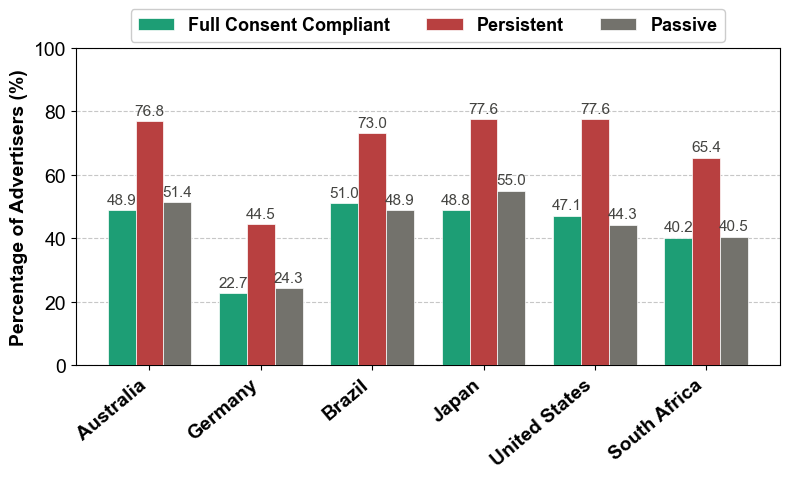

In [15]:

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
TRACKING_DIR = Path("../dataset/AdHoc_Report_3rdPartyTrackingCookie")   # or wherever 3rd_party_trackingcookie files are
CATEGORY_DIR = Path("output_data/country_behaviour_lists")   # where {country}_full_compliance.csv etc. are saved

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def has_third_party_violation(df):
    """
    True if any unique_run_1..5 > 0 in a row.
    """
    unique_cols = [f"unique_run_{i}" for i in range(1, 6)]
    existing_cols = [c for c in unique_cols if c in df.columns]
    if not existing_cols:
        return pd.Series(False, index=df.index)
    return df[existing_cols].fillna(0).gt(0).any(axis=1)

def evaluate_category_domains(domains, reject_df, no_df):
    """
    For a given set/list of domains, return a per-domain dataframe with:
      - category domain
      - reject_violation
      - no_interaction_violation
      - non_compliant_3rd
      - 3rd_compliant
    Rule:
      unique_run_1..5 > 0 on reject-all OR no-interaction => NON-COMPLIANT
    """
    domains = pd.Index(sorted(set(domains)), name="domain")
    out = pd.DataFrame({"domain": domains})

    reject_sub = reject_df[reject_df["domain"].isin(domains)].copy()
    no_sub     = no_df[no_df["domain"].isin(domains)].copy()

    reject_bad_domains = set(reject_sub.loc[has_third_party_violation(reject_sub), "domain"])
    no_bad_domains     = set(no_sub.loc[has_third_party_violation(no_sub), "domain"])

    out["reject_violation"]         = out["domain"].isin(reject_bad_domains)
    out["no_interaction_violation"] = out["domain"].isin(no_bad_domains)
    out["non_compliant_3rd"]        = out["reject_violation"] | out["no_interaction_violation"]
    out["3rd_compliant"]            = ~out["non_compliant_3rd"]

    return out

# ------------------------------------------------------------
# Build per-country category compliance files
# ------------------------------------------------------------
summary_rows = []

for country in COUNTRIES:
    # --- Load category files ---
    full_path       = CATEGORY_DIR / f"{country}_full_compliance.csv"
    persistent_path = CATEGORY_DIR / f"{country}_persistent.csv"
    passive_path    = CATEGORY_DIR / f"{country}_passive.csv"

    full_df       = pd.read_csv(full_path)
    persistent_df = pd.read_csv(persistent_path)
    passive_df    = pd.read_csv(passive_path)

    # --- Load 3rd-party cookie files ---
    reject_df = pd.read_csv(TRACKING_DIR / f"3rd_party_trackingcookie_{country}_reject-all.csv")
    no_df     = pd.read_csv(TRACKING_DIR / f"3rd_party_trackingcookie_{country}_no-interaction.csv")

    # Normalize advertiser column -> domain
    reject_df["domain"] = reject_df["advertiser_url"].apply(get_registered_domain)
    no_df["domain"]     = no_df["advertiser_url"].apply(get_registered_domain)
    # Optional cleanup
    reject_df["domain"] = reject_df["domain"].astype(str).str.strip()
    no_df["domain"]     = no_df["domain"].astype(str).str.strip()

    full_domains       = full_df["domain"].astype(str).str.strip().tolist()
    persistent_domains = persistent_df["domain"].astype(str).str.strip().tolist()
    passive_domains    = passive_df["domain"].astype(str).str.strip().tolist()

    # --- Evaluate each category ---
    full_out = evaluate_category_domains(full_domains, reject_df, no_df)
    full_out["category"] = "Full Consent Compliant"

    persistent_out = evaluate_category_domains(persistent_domains, reject_df, no_df)
    persistent_out["category"] = "Persistent"

    passive_out = evaluate_category_domains(passive_domains, reject_df, no_df)
    passive_out["category"] = "Passive"

    # --- Combine and save ---
    country_out = pd.concat([full_out, persistent_out, passive_out], ignore_index=True)
    country_out = country_out[
        [
            "category",
            "domain",
            "reject_violation",
            "no_interaction_violation",
            "non_compliant_3rd",
            "3rd_compliant",
        ]
    ]

    out_path = Path(DIR_OUTPUT_DATA) / f"consent_3rdparty_{country}.csv"
    country_out.to_csv(out_path, index=False)

    # --- Summary stats ---
    for cat in ["Full Consent Compliant", "Persistent", "Passive"]:
        sub = country_out[country_out["category"] == cat]
        n_total = len(sub)
        n_noncompliant = int(sub["non_compliant_3rd"].sum())
        pct_noncompliant = (n_noncompliant / n_total * 100) if n_total else 0.0

        summary_rows.append({
            "country": country,
            "category": cat,
            "n_total": n_total,
            "n_noncompliant_3rd": n_noncompliant,
            "pct_noncompliant_3rd": pct_noncompliant,
        })

    print(
        f"{country}: saved {out_path.name} | "
        f"Full={len(full_out)}, Persistent={len(persistent_out)}, Passive={len(passive_out)}"
    )

summary_3rd_df = pd.DataFrame(summary_rows)
summary_3rd_df.to_csv(Path(DIR_OUTPUT_DATA) / "consent_3rdparty_summary_by_country_category.csv", index=False)

print("\n3rd-party non-compliance summary:")
print(summary_3rd_df.to_string(index=False))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
CATEGORIES = ['Full Consent Compliant', 'Persistent', 'Passive']

noncompliance = {cat: [] for cat in CATEGORIES}

for country in COUNTRIES:
    try:
        df = pd.read_csv(f"{DIR_OUTPUT_DATA}/consent_3rdparty_{country}.csv")
        for cat in CATEGORIES:
            sub = df[df['category'] == cat]
            pct = ((sub['3rd_compliant'] == False).sum() / len(sub) * 100) if len(sub) else 0.0
            noncompliance[cat].append(round(pct, 1))
            print(f"{country} - {cat}: {pct:.1f}% non-compliant - {(sub['3rd_compliant'] == False).sum()}/{len(sub)}")
    except Exception as e:
        print(f"Skipping {country}: {e}")
        for cat in CATEGORIES:
            noncompliance[cat].append(0.0)

labels = [COUNTRY_LABELS[c] for c in COUNTRIES]
x      = np.arange(len(COUNTRIES))
width  = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bar_kwargs = dict(edgecolor='white', linewidth=0.5, zorder=3)
bars1 = ax.bar(x - width, noncompliance['Full Consent Compliant'], width,
               label="Full Consent Compliant", color=COLORS["correct"], **bar_kwargs)
bars2 = ax.bar(x, noncompliance['Persistent'], width,
               label="Persistent", color=COLORS["always_set"], **bar_kwargs)
bars3 = ax.bar(x + width, noncompliance['Passive'], width,
               label="Passive", color=COLORS["never_set"], **bar_kwargs)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 1,
                f"{h:.1f}",
                ha='center',
                va='bottom',
                fontsize=11,
                color='#444441'
            )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage of Advertisers (%)', fontsize=14, fontweight='bold')
# ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=14, fontproperties=helvetica_bold)
# ax.set_ylabel('Percentage of Advertisers (%)', fontsize=14, fontproperties=helvetica_bold)
ax.set_ylim(0, 100)
plt.yticks(fontsize=14)

legend = ax.legend(fontsize=13, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, framealpha=1)
bold_legend(legend)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{DIR_OUTPUT_FIGS}/noncompliance_3rdcookie_by_category_country.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

## Export Per-Country Domain Lists (with / without Banner)

In [16]:
for country in COUNTRIES:
    accept_s = get_domain_level_df(FILES_1ST[country]['accept-all']).reindex(INTERSECT_INDEX, fill_value=False)
    reject_s = get_domain_level_df(FILES_1ST[country]['reject-all']).reindex(INTERSECT_INDEX, fill_value=False)

    can_both       = accept_s["observed"] & reject_s["observed"]
    no_banner_mask = ~(accept_s["observed"] | reject_s["observed"])

    pd.DataFrame({"domain": INTERSECT_INDEX[can_both]}).to_csv(
        f"{DIR_OUTPUT_DATA}/domains_{country}_with_banner.csv", index=False)
    pd.DataFrame({"domain": INTERSECT_INDEX[no_banner_mask]}).to_csv(
        f"{DIR_OUTPUT_DATA}/domains_{country}_without_banner.csv", index=False)

    print(f"{COUNTRY_LABELS[country]}: "
          f"{can_both.sum()} with banner, {no_banner_mask.sum()} without banner")

Australia: 478 with banner, 934 without banner
Germany: 605 with banner, 807 without banner
Brazil: 484 with banner, 928 without banner
Japan: 475 with banner, 937 without banner
United States: 504 with banner, 908 without banner
South Africa: 475 with banner, 937 without banner


## 3rd-Party GCLID – Data Loaders

In [17]:
def load_banner_domains(code):
    """Return (with_banner_set, without_banner_set) for a country code."""
    with_banner    = set(pd.read_csv(f"{DIR_OUTPUT_DATA}/domains_{code}_with_banner.csv")["domain"].dropna().unique())
    without_banner = set(pd.read_csv(f"{DIR_OUTPUT_DATA}/domains_{code}_without_banner.csv")["domain"].dropna().unique())
    return with_banner, without_banner


def load_flow_csvs(code):
    """Load all three consent-flow CSVs for a country; add a 'domain' column."""
    dfs = {}
    for name in FLOWS:
        path = f"{BASE_3RD}/3rdDomain_received_{code}_{name}.csv"
        df   = pd.read_csv(path)
        df['domain'] = df['advertiserDomain']
        dfs[name] = df
    return dfs


def build_avg_receivers(df, type_label, full_name, valid_domains):
    """
    For a given flow DataFrame and domain subset, compute the per-domain
    average number of unique third-party receivers across runs.
    Domains with no records are assigned 0.
    """
    df_filtered = df[df['domain'].isin(valid_domains)]

    if df_filtered.empty:
        avg_df = pd.DataFrame({"domain": [], "avg": []})
    else:
        avg_df = (
            df_filtered
            .groupby(['domain', 'run_no'])['third_domain']
            .nunique()
            .reset_index()
            .groupby('domain')['third_domain']
            .mean()
            .reset_index()
            .rename(columns={'third_domain': 'avg'})
        )

    missing = valid_domains - set(avg_df['domain'])
    if missing:
        avg_df = pd.concat(
            [avg_df, pd.DataFrame({"domain": list(missing), "avg": 0.0})],
            ignore_index=True,
        )

    return pd.DataFrame({
        'location':     full_name,
        'count':        avg_df['avg'].values,
        'request_type': type_label,
    })

## Plot 4 – Boxplot: Avg 3rd-Party Receivers per Country & Condition


                   BOXPLOT METRICS PER COUNTRY AND CONDITION                    
                              min   25%       50%    median   75%        max      mean       std  count
location      request_type                                                                             
Australia     Accept All      0.0  3.50  6.000000  6.000000  8.80  42.500000  6.786646  5.233341  478.0
              No Banner       0.0  3.00  5.800000  5.800000  8.00  45.400000  6.543255  5.297356  934.0
              No Interaction  1.0  2.00  5.000000  5.000000  8.00  47.000000  5.897490  5.066713  478.0
              Reject All      0.0  2.00  4.600000  4.600000  7.20  50.000000  5.369944  4.751199  478.0
Brazil        Accept All      0.0  3.00  5.733333  5.733333  8.60  40.400000  6.437259  5.136458  484.0
              No Banner       0.0  2.75  5.400000  5.400000  8.00  37.400000  6.203358  4.819008  928.0
              No Interaction  1.0  2.00  4.000000  4.000000  7.00  36.600000  5.283299

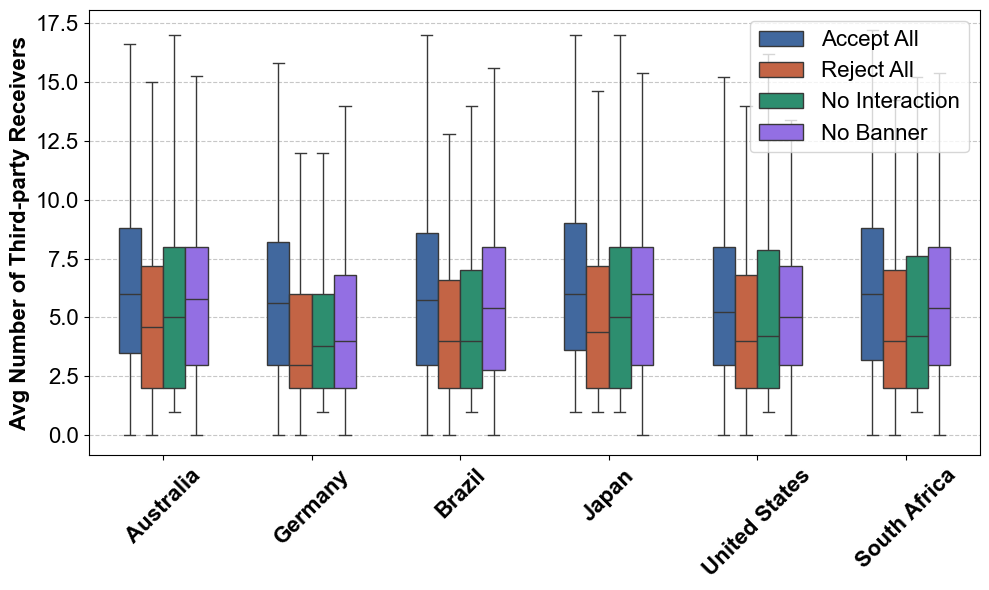

In [18]:
all_data_frames = []

for code, full_name in COUNTRY_LABELS.items():
    try:
        with_banner, without_banner = load_banner_domains(code)
        dfs = load_flow_csvs(code)

        all_data_frames.append(build_avg_receivers(dfs['accept-all'],     REQ_TYPES[0], full_name, with_banner))
        all_data_frames.append(build_avg_receivers(dfs['reject-all'],     REQ_TYPES[1], full_name, with_banner))
        all_data_frames.append(build_avg_receivers(dfs['no-interaction'], REQ_TYPES[2], full_name, with_banner))
        all_data_frames.append(build_avg_receivers(dfs['no-interaction'], REQ_TYPES[3], full_name, without_banner))

    except Exception as e:
        print(f"Skipping {code}: {e}")

combined_df = pd.concat(all_data_frames, ignore_index=True)

# Summary stats
print("\n" + "="*80)
print(f"{'BOXPLOT METRICS PER COUNTRY AND CONDITION':^80}")
print("="*80)
stats = combined_df.groupby(['location', 'request_type'])['count'].describe()
stats['median'] = combined_df.groupby(['location', 'request_type'])['count'].median()
print(stats[['min', '25%', '50%', 'median', '75%', 'max', 'mean', 'std', 'count']].to_string())

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='location', y='count', hue='request_type',
    data=combined_df, width=0.6,
    palette={
        REQ_TYPES[0]: '#3266AD',
        REQ_TYPES[1]: '#D85A30',
        REQ_TYPES[2]: '#1D9E75',
        REQ_TYPES[3]: '#8B5CF6',
    },
    showfliers=False,
)
plt.xlabel('', fontsize=16)
plt.ylabel('Avg Number of Third-party Receivers', fontsize=16, weight='bold')
plt.xticks(rotation=45, fontsize=16, weight='bold')
plt.yticks(fontsize=16)
plt.legend(fontsize=16, loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{DIR_OUTPUT_FIGS}/grouped_3rdparty_all_countries.pdf', format='pdf')
plt.show()

## Plot 5 – Jaccard Similarity Heatmap of 3rd-Party Trackers

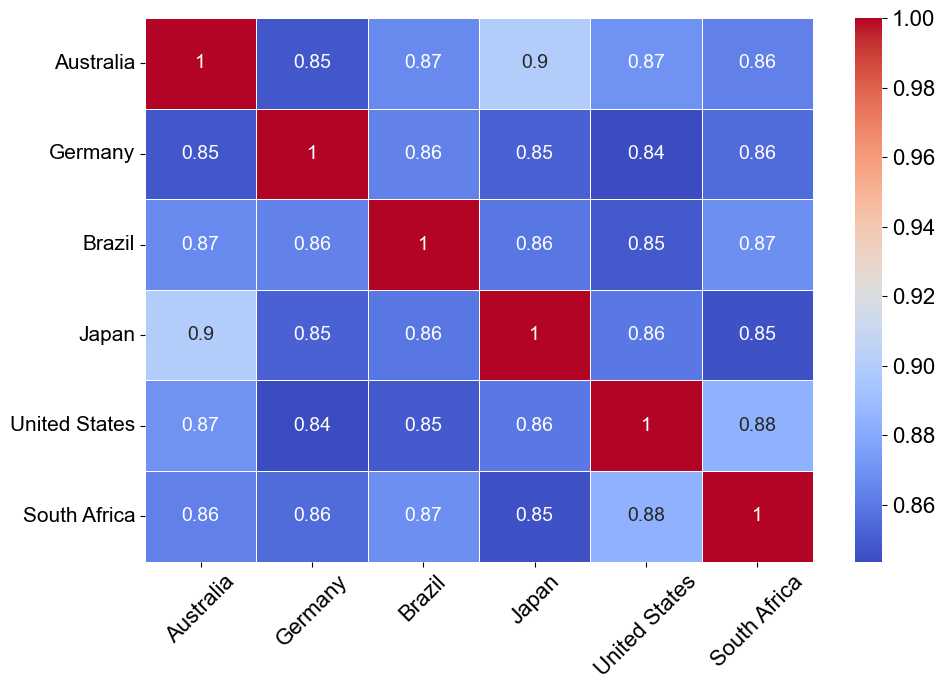


Individual Tracker Counts:
Australia: 683 unique third-party domains
Germany: 642 unique third-party domains
Brazil: 644 unique third-party domains
Japan: 691 unique third-party domains
United States: 691 unique third-party domains
South Africa: 664 unique third-party domains


In [19]:
country_tracker_sets = {}

for code, full_name in COUNTRY_LABELS.items():
    trackers = set()
    try:
        with_banner, without_banner = load_banner_domains(code)
        dfs = load_flow_csvs(code)

        for name, df in dfs.items():
            if name in ['accept-all', 'reject-all']:
                df = df[df['domain'].isin(with_banner)]
            else:
                df = pd.concat([
                    df[df['domain'].isin(with_banner)],
                    df[df['domain'].isin(without_banner)],
                ], ignore_index=True)
            if 'third_domain' in df.columns:
                trackers.update(df['third_domain'].dropna().unique())

        country_tracker_sets[full_name] = trackers

    except Exception as e:
        print(f"Skipping {code}: {e}")
        country_tracker_sets[full_name] = set()

# Jaccard matrix
n      = len(FULL_NAMES)
matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        s_i = country_tracker_sets[FULL_NAMES[i]]
        s_j = country_tracker_sets[FULL_NAMES[j]]
        if not s_i or not s_j:
            matrix[i, j] = 1.0 if i == j else 0.0
        else:
            matrix[i, j] = len(s_i & s_j) / len(s_i | s_j)

df_similarity = pd.DataFrame(matrix, index=FULL_NAMES, columns=FULL_NAMES)

plt.figure(figsize=(10, 7))
sns.heatmap(df_similarity, annot=True, annot_kws={"size": 14},
            cmap='coolwarm', cbar=True, linewidths=0.5)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(rotation=0,  fontsize=15)
plt.gcf().axes[-1].tick_params(labelsize=16)
plt.tight_layout()
plt.savefig(f'{DIR_OUTPUT_FIGS}/jaccard_similarity_heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\nIndividual Tracker Counts:")
for country, trackers in country_tracker_sets.items():
    print(f"{country}: {len(trackers)} unique third-party domains")

## Plot 6 – 3rd-Party Domain Overlap: Accept-Only vs Reject-Only vs Shared

AU  with-banner=478  common=477  total=407   acc-only=84  rej-only=17  shared=306
DE  with-banner=605  common=604  total=469   acc-only=125  rej-only=8  shared=336
BR  with-banner=484  common=483  total=383   acc-only=87  rej-only=7  shared=289
JP  with-banner=475  common=475  total=394   acc-only=73  rej-only=7  shared=314
US  with-banner=504  common=503  total=425   acc-only=74  rej-only=15  shared=336
ZA  with-banner=475  common=474  total=390   acc-only=90  rej-only=4  shared=296


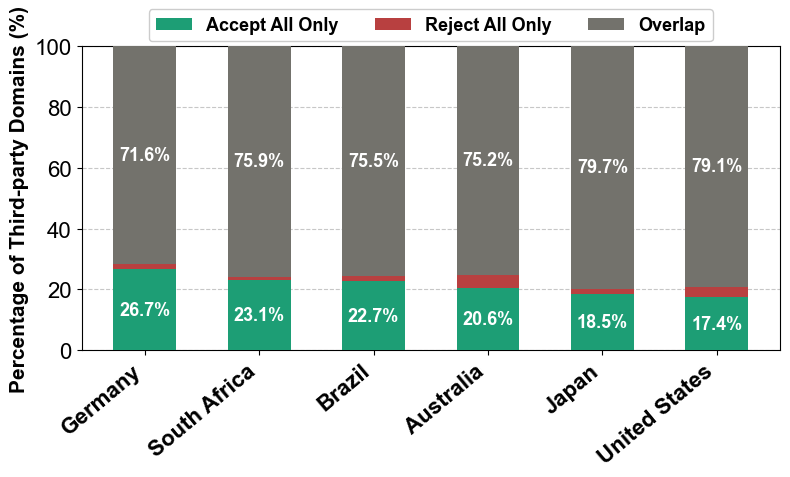

In [20]:
overlap_results = {}

for c in COUNTRIES:
    f_acc = f"{BASE_3RD}/3rdDomain_received_{c}_accept-all.csv"
    f_rej = f"{BASE_3RD}/3rdDomain_received_{c}_reject-all.csv"
    if not (os.path.exists(f_acc) and os.path.exists(f_rej)):
        print(f"Skipping {c} (missing files)")
        continue
    try:
        with_banner, _ = load_banner_domains(c)

        df_acc = pd.read_csv(f_acc)
        df_rej = pd.read_csv(f_rej)
        for df in [df_acc, df_rej]:
            df['domain']       = df['advertiserDomain'].astype(str).str.strip().str.lower()
            df['third_domain'] = df['third_domain'].astype(str).str.strip().str.lower()

        df_acc = df_acc[df_acc['domain'].isin(with_banner)]
        df_rej = df_rej[df_rej['domain'].isin(with_banner)]

        common_adv = set(df_acc['advertiserDomain']) & set(df_rej['advertiserDomain'])
        df_acc = df_acc[df_acc['advertiserDomain'].isin(common_adv)]
        df_rej = df_rej[df_rej['advertiserDomain'].isin(common_adv)]

        acc_domains = set(df_acc['third_domain'])
        rej_domains = set(df_rej['third_domain'])
        shared      = acc_domains & rej_domains
        acc_only    = acc_domains - rej_domains
        rej_only    = rej_domains - acc_domains
        total       = len(acc_domains | rej_domains)

        overlap_results[c] = {
            "pct_accept_only": safe_pct(len(acc_only), total),
            "pct_reject_only": safe_pct(len(rej_only), total),
            "pct_shared":      safe_pct(len(shared),   total),
            "n_total":         total,
        }
        print(f"{c}  with-banner={len(with_banner)}  common={len(common_adv)}  "
              f"total={total}   acc-only={len(acc_only)}  rej-only={len(rej_only)}  shared={len(shared)}")

    except Exception as e:
        print(f"Error in {c}: {e}")

sorted_items    = sorted(overlap_results.items(), key=lambda x: x[1]["pct_accept_only"], reverse=True)
countries_s     = [c for c, _ in sorted_items]
labels_s        = [COUNTRY_LABELS[c] for c in countries_s]
pct_accept_only = [v["pct_accept_only"] for _, v in sorted_items]
pct_reject_only = [v["pct_reject_only"] for _, v in sorted_items]
pct_shared      = [v["pct_shared"]      for _, v in sorted_items]

x     = range(len(countries_s))
width = 0.55

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x, pct_accept_only, width, label="Accept All Only", color="#1D9E75", zorder=3)
b2 = ax.bar(x, pct_reject_only, width, label="Reject All Only", color="#B84040", zorder=3,
            bottom=pct_accept_only)
b3 = ax.bar(x, pct_shared,      width, label="Overlap",         color="#73726C", zorder=3,
            bottom=[a + b for a, b in zip(pct_accept_only, pct_reject_only)])

label_bar_segments(ax, b1, [0] * len(countries_s))
label_bar_segments(ax, b2, pct_accept_only)
label_bar_segments(ax, b3, [a + b for a, b in zip(pct_accept_only, pct_reject_only)])

ax.set_xticks(list(x))
ax.set_xticklabels(labels_s, rotation=40, ha='right', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentage of Third-party Domains (%)', fontsize=15, fontweight='bold')
# ax.set_xticklabels(labels_s, rotation=40, ha='right', fontsize=16, fontproperties=helvetica_bold)
# ax.set_ylabel('Percentage of Third-party Domains (%)', fontsize=16, fontproperties=helvetica_bold)
ax.set_ylim(0, 100)
plt.yticks(fontsize=16)

legend = ax.legend(fontsize=13, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, framealpha=1)
bold_legend(legend)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{DIR_OUTPUT_FIGS}/gclid_overlap_accept_reject.pdf", bbox_inches="tight")
plt.show()

In [21]:
# Collect reject-only domains per country
reject_only_records = []

for c in COUNTRIES:
    f_acc = f"{BASE_3RD}/3rdDomain_received_{c}_accept-all.csv"
    f_rej = f"{BASE_3RD}/3rdDomain_received_{c}_reject-all.csv"
    if not (os.path.exists(f_acc) and os.path.exists(f_rej)):
        continue
    try:
        with_banner, _ = load_banner_domains(c)
        df_acc = pd.read_csv(f_acc)
        df_rej = pd.read_csv(f_rej)

        for df in [df_acc, df_rej]:
            df['domain']       = df['advertiserDomain'].astype(str).str.strip().str.lower()
            df['third_domain'] = df['third_domain'].astype(str).str.strip().str.lower()

        df_acc = df_acc[df_acc['domain'].isin(with_banner)]
        df_rej = df_rej[df_rej['domain'].isin(with_banner)]

        common_adv = set(df_acc['advertiserDomain']) & set(df_rej['advertiserDomain'])
        df_acc = df_acc[df_acc['advertiserDomain'].isin(common_adv)]
        df_rej = df_rej[df_rej['advertiserDomain'].isin(common_adv)]

        acc_domains = set(df_acc['third_domain'])
        rej_domains = set(df_rej['third_domain'])
        rej_only    = rej_domains - acc_domains

        for domain in sorted(rej_only):
            reject_only_records.append({"country": c, "third_domain": domain})

    except Exception as e:
        print(f"Error in {c}: {e}")

# Build a DataFrame and display / save
df_rej_only = pd.DataFrame(reject_only_records)
print(df_rej_only)

# Optional: save to CSV
df_rej_only.to_csv(f"{DIR_OUTPUT_DATA}/reject_only_domains.csv", index=False)

   country                 third_domain
0       AU                 akamaihd.net
1       AU                appsflyer.com
2       AU          attentivemobile.com
3       AU              bazaarvoice.com
4       AU  datadoghq-browser-agent.com
5       AU                      dv.tech
6       AU          getsmartcontent.com
7       AU                  im-apps.net
8       AU                   invoca.net
9       AU                    liadm.com
10      AU                metricool.com
11      AU               onetag-sys.com
12      AU           requestmetrics.com
13      AU                 rtbhouse.com
14      AU             secureserver.net
15      AU                  youtube.com
16      AU                  zineone.com
17      DE                   affirm.com
18      DE          betterstackdata.com
19      DE                metricool.com
20      DE                newsbreak.com
21      DE                    noibu.com
22      DE                 onetrust.com
23      DE                  srvmath.com


## Plot 7 – Top 10 3rd-Party Domains per Country

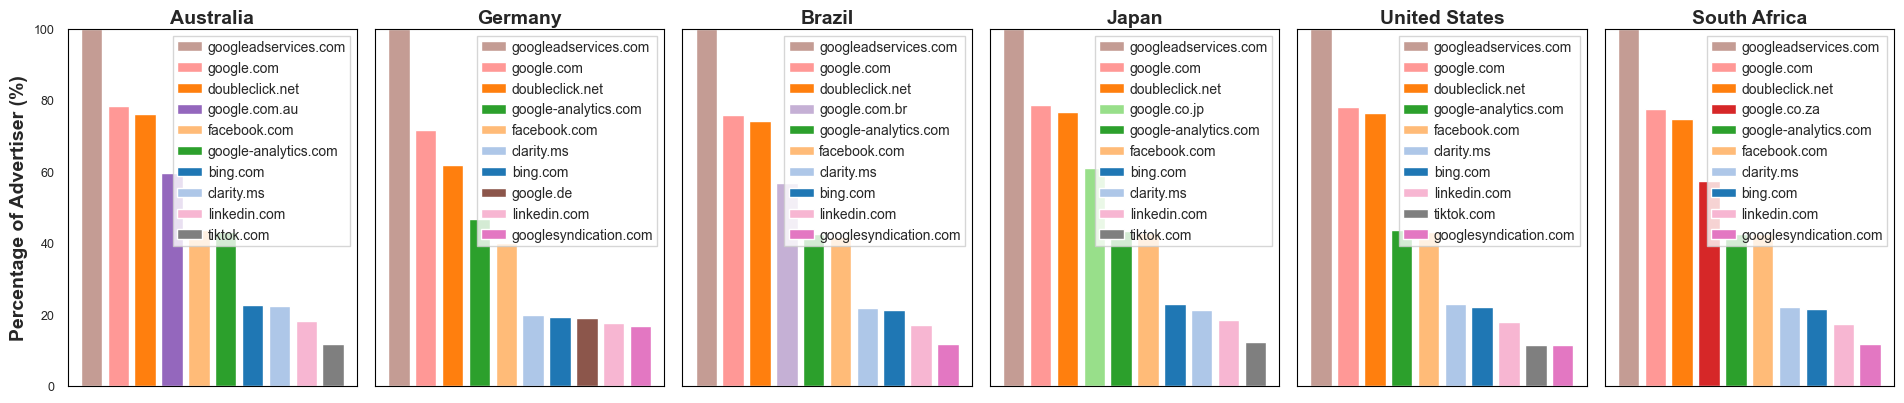

In [22]:
vp_results     = {}
all_top_domains = set()

for code in COUNTRIES:
    try:
        raw_dfs    = []
        unique_ads = set()

        for name in FLOWS:
            path = f'{BASE_3RD}/3rdDomain_received_{code}_{name}.csv'
            df   = pd.read_csv(path)
            df['third_domain'] = df['third_domain'].astype(str).str.lower().str.strip().str.lstrip('.')
            df['advertiser']   = df['advertiserDomain'].astype(str).str.strip().str.lower()
            unique_ads.update(df['advertiser'].dropna().unique())
            raw_dfs.append(df[['advertiser', 'third_domain']].drop_duplicates())

        combined = pd.concat(raw_dfs).drop_duplicates()
        total    = len(unique_ads)

        counts = combined['third_domain'].value_counts().head(10).reset_index()
        counts.columns = ['Domain', 'Prev']
        counts['Prev'] = (counts['Prev'] / total) * 100

        vp_results[code] = counts
        all_top_domains.update(counts['Domain'].tolist())

    except Exception as e:
        print(f"Error {code}: {e}")

# Consistent colour mapping across subplots
sns.set_theme(style="white")
sorted_domains = sorted(all_top_domains)
palette        = sns.color_palette("tab20", len(sorted_domains))
color_map      = {domain: palette[i] for i, domain in enumerate(sorted_domains)}

fig, axes = plt.subplots(1, len(COUNTRIES), figsize=(3.2 * len(COUNTRIES), 4.2), sharey=True)
if len(COUNTRIES) == 1:
    axes = [axes]

for ax, code in zip(axes, COUNTRIES):
    if code not in vp_results:
        ax.axis("off")
        continue

    data   = vp_results[code]
    colors = [color_map[d] for d in data['Domain']]

    bars = ax.bar(range(len(data)), data['Prev'], color=colors, width=0.8)
    ax.set_title(COUNTRY_LABELS[code], fontsize=14, pad=4, weight='bold')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('black')
    ax.legend(bars, data['Domain'], loc='upper right', fontsize=10,
              frameon=True, fancybox=False, borderpad=0.3,
              handlelength=1.8, handletextpad=0.4)

axes[0].set_ylabel("Percentage of Advertiser (%)", fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_OUTPUT_FIGS}/top_domains.pdf', format='pdf', bbox_inches='tight')
plt.show()